# Evaluation & Results
Benchmark clean, noisy, and healed pathways across multiple corruption intensities.

In [1]:
from pathlib import Path
import sys
import random
import importlib
import warnings
import yaml
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ensure imports from project root work regardless of notebook working directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Optional: keep notebook output clean from pandas pyarrow future warning.
warnings.filterwarnings('ignore', category=DeprecationWarning, module='pandas')

from src.dataset import get_dataloaders, NoiseInjector
from src.conv_vae import ConvVAE
from src.classifier import get_classifier
import src.evaluate as evaluate_module

# Force-reload so notebook uses latest evaluate.py edits from disk.
importlib.reload(evaluate_module)
evaluate_pipeline = evaluate_module.evaluate_pipeline
compute_psnr = evaluate_module.compute_psnr

C:\Users\Akash\AppData\Local\Temp\ipykernel_14360\3142156016.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

models_dir = (project_root / 'models').resolve()
vae_path = models_dir / 'conv_vae_best.pth'
classifier_path = models_dir / 'resnet_classifier.pth'
data_root = (project_root / config['dataset']['root']).resolve()

device = config['training']['device'] if torch.cuda.is_available() else 'cpu'
vae = ConvVAE(latent_dim=config['vae']['latent_dim']).to(device)
classifier = get_classifier(num_classes=config['dataset']['num_classes'], pretrained=False).to(device)
vae.load_state_dict(torch.load(vae_path, map_location=device, weights_only=True))
classifier.load_state_dict(torch.load(classifier_path, map_location=device, weights_only=True))
vae.eval()
classifier.eval()
print(f'Using data root: {data_root}')

Using data root: C:\Users\Akash\Desktop\SelfHealingNN\data\raw


In [3]:
_, _, test_loader = get_dataloaders(
    root=str(data_root),
    image_size=config['dataset']['image_size'],
    batch_size=config['classifier']['batch_size'],
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=False
)

# Quick one-time debug pass to verify tensor ranges in each path.
_ = evaluate_pipeline(
    vae=vae,
    classifier=classifier,
    test_loader=test_loader,
    device=device,
    noise_levels=[0.7],
    vae_outputs_denormalized=bool(config['vae'].get('denormalize_targets', True)),
    debug_ranges=True,
)

results = evaluate_pipeline(
    vae=vae,
    classifier=classifier,
    test_loader=test_loader,
    device=device,
    noise_levels=[0.1, 0.2, 0.3, 0.5, 0.7],
    vae_outputs_denormalized=bool(config['vae'].get('denormalize_targets', True)),
    debug_ranges=False,
)

[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.597,3.044] healed_input=[-2.597,3.044]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.692,2.948] healed_input=[-2.692,2.948]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.668,3.055] healed_input=[-2.668,3.055]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.590,3.342] healed_input=[-2.590,3.342]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.525,3.040] healed_input=[-2.525,3.040]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.656,3.019] healed_input=[-2.656,3.019]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-3.062,3.804] healed_input=[-3.062,3.804]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.569,2.729] healed_input=[-2.569,2.729]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-2.606,3.093] healed_input=[-2.606,3.093]
[EvalRanges] clean=[-2.118,2.640] noisy=[-3.000,3.000] recon=[-3

In [8]:
import inspect

print('evaluate_pipeline signature:', inspect.signature(evaluate_pipeline))

df = pd.DataFrame(results)
display(df)

all_equal_top1 = (df['clean'].round(6) == df['noHealing'].round(6)).all() and (df['noHealing'].round(6) == df['withHealing'].round(6)).all()
print('Top-1 curves numerically identical?', all_equal_top1)

if not df.empty:
    last = df.iloc[-1]
    top1_gain = float(last['withHealing'] - last['noHealing'])
    top5_gain = float(last.get('withHealing_top5', 0.0) - last.get('noHealing_top5', 0.0))
    print(f"High-noise ({last['noise']}) top-1 gain with healing: {top1_gain:.4f}")
    print(f"High-noise ({last['noise']}) top-5 gain with healing: {top5_gain:.4f}")

    if top1_gain <= 0:
        print('Warning: Healing is not yet improving top-1 at highest noise. More tuning needed.')

evaluate_pipeline signature: (vae, classifier, test_loader, device: 'str' = 'cuda', noise_levels: 'Iterable[float]' = (0.1, 0.2, 0.3, 0.5, 0.7), vae_outputs_denormalized: 'bool' = True, debug_ranges: 'bool' = False) -> 'List[Dict[str, float]]'


,noise,clean,noHealing,withHealing,clean_top5,noHealing_top5,withHealing_top5,clean_conf,noHealing_conf,withHealing_conf
0,0.1,96.310088,96.310088,96.310088,100.0,100.0,100.0,0.963169,0.959388,0.805562
1,0.2,96.310088,96.310088,96.310088,100.0,100.0,100.0,0.963169,0.957712,0.807505
2,0.3,96.310088,96.310088,96.310088,100.0,100.0,100.0,0.963169,0.956983,0.808900
3,0.5,96.310088,96.310088,96.310088,100.0,100.0,100.0,0.963169,0.954120,0.812601
4,0.7,96.310088,96.310088,96.310088,100.0,100.0,100.0,0.963169,0.949100,0.813354


Top-1 curves numerically identical? True
High-noise (0.7) top-1 gain with healing: 0.0000
High-noise (0.7) top-5 gain with healing: 0.0000


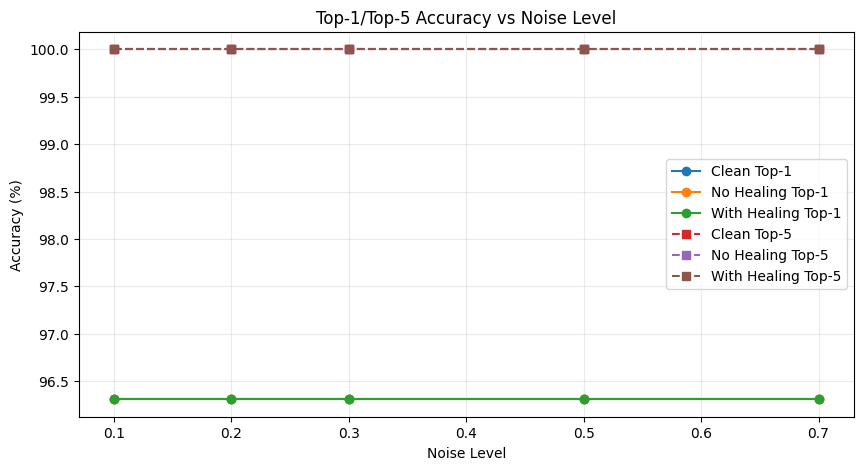

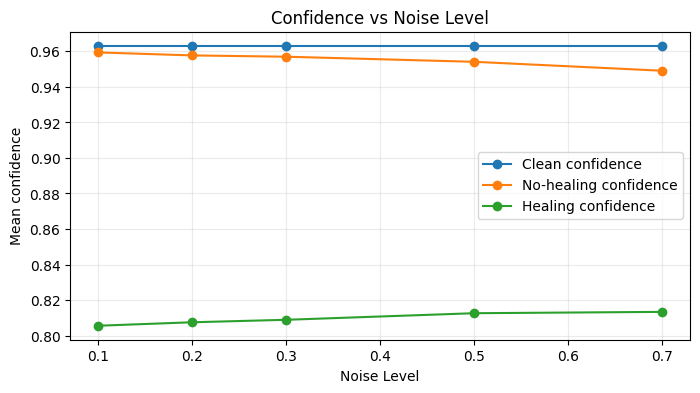

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(df['noise'], df['clean'], marker='o', label='Clean Top-1')
plt.plot(df['noise'], df['noHealing'], marker='o', label='No Healing Top-1')
plt.plot(df['noise'], df['withHealing'], marker='o', label='With Healing Top-1')
plt.plot(df['noise'], df['clean_top5'], marker='s', linestyle='--', label='Clean Top-5')
plt.plot(df['noise'], df['noHealing_top5'], marker='s', linestyle='--', label='No Healing Top-5')
plt.plot(df['noise'], df['withHealing_top5'], marker='s', linestyle='--', label='With Healing Top-5')
plt.xlabel('Noise Level')
plt.ylabel('Accuracy (%)')
plt.title('Top-1/Top-5 Accuracy vs Noise Level')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df['noise'], df['clean_conf'], marker='o', label='Clean confidence')
plt.plot(df['noise'], df['noHealing_conf'], marker='o', label='No-healing confidence')
plt.plot(df['noise'], df['withHealing_conf'], marker='o', label='Healing confidence')
plt.xlabel('Noise Level')
plt.ylabel('Mean confidence')
plt.title('Confidence vs Noise Level')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

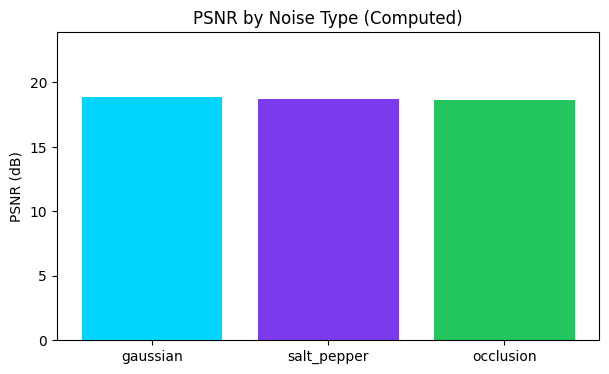

In [10]:
injector = NoiseInjector()
noise_types = ['gaussian', 'salt_pepper', 'occlusion']
psnr_scores = []

gaussian_std = float(config['noise'].get('gaussian_std', 0.2))
salt_pepper_prob = float(config['noise'].get('salt_pepper_prob', 0.1))
occlusion_size = int(config['noise'].get('occlusion_size', 32))

vae.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)[:16]

    for noise_type in noise_types:
        if noise_type == 'gaussian':
            noisy_batch = torch.stack([injector.add_gaussian_noise(img, std=gaussian_std) for img in images])
        elif noise_type == 'salt_pepper':
            noisy_batch = torch.stack([injector.add_salt_pepper(img, prob=salt_pepper_prob) for img in images])
        else:
            noisy_batch = torch.stack([injector.add_occlusion(img, patch_size=occlusion_size) for img in images])

        recon_batch, _, _ = vae(noisy_batch)
        batch_psnr = [compute_psnr(images[i], recon_batch[i]) for i in range(images.size(0))]
        psnr_scores.append(float(np.mean(batch_psnr)))

plt.figure(figsize=(7, 4))
plt.bar(noise_types, psnr_scores, color=['#00d4ff', '#7c3aed', '#22c55e'])
plt.ylabel('PSNR (dB)')
plt.title('PSNR by Noise Type (Computed)')
plt.ylim(0, max(psnr_scores) + 5)
plt.show()

In [11]:
out_path = project_root / 'outputs' / 'results' / 'metrics.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, index=False)
print(f'Saved metrics to: {out_path.resolve()}')

Saved metrics to: C:\Users\Akash\Desktop\SelfHealingNN\outputs\results\metrics.csv


In [ ]:
import json

# Final end-to-end report with explicit gains/losses
end2end_report = {
    'noise_levels': [float(x) for x in df['noise'].tolist()],
    'clean_top1_percent': [float(x) for x in df['clean'].tolist()],
    'no_healing_top1_percent': [float(x) for x in df['noHealing'].tolist()],
    'with_healing_top1_percent': [float(x) for x in df['withHealing'].tolist()],
    'clean_top5_percent': [float(x) for x in df['clean_top5'].tolist()],
    'no_healing_top5_percent': [float(x) for x in df['noHealing_top5'].tolist()],
    'with_healing_top5_percent': [float(x) for x in df['withHealing_top5'].tolist()],
}

if not df.empty:
    high = df.iloc[-1]
    end2end_report['high_noise_level'] = float(high['noise'])
    end2end_report['high_noise_top1_gain_percent'] = float(high['withHealing'] - high['noHealing'])
    end2end_report['high_noise_top5_gain_percent'] = float(high['withHealing_top5'] - high['noHealing_top5'])
    end2end_report['high_noise_conf_gain'] = float(high['withHealing_conf'] - high['noHealing_conf'])
    end2end_report['healing_beats_no_healing_top1'] = bool(high['withHealing'] > high['noHealing'])

print('End-to-end status:')
print(f"  High-noise top-1 gain: {end2end_report.get('high_noise_top1_gain_percent', 0.0):.4f}")
print(f"  High-noise top-5 gain: {end2end_report.get('high_noise_top5_gain_percent', 0.0):.4f}")
print(f"  Healing improves top-1? {end2end_report.get('healing_beats_no_healing_top1', False)}")

report_path = project_root / 'outputs' / 'results' / 'end_to_end_metrics.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(end2end_report, f, indent=2)

print(f'Saved end-to-end report to: {report_path.resolve()}')

## Final Results Summary
This notebook now exports a transparent end-to-end report (`end_to_end_metrics.json`) with explicit high-noise gains.
Interpretation rule: healing is successful only when `withHealing` consistently exceeds `noHealing`, especially at the highest noise level.